In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

%matplotlib inline

torch.manual_seed(42)
np.random.seed(42)

In [2]:
device = (
    'cuda' if torch.cuda.is_available() else
    'mps' if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available() else
    'cpu'
)
print('device:', device)

device: cpu


In [4]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=transform,
)

print('train size:', len(train_dataset))
print('test size :', len(test_dataset))

100%|██████████| 28.9k/28.9k [00:00<00:00, 137kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.07MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.69MB/s]


train size: 60000
test size : 10000


single image shape: torch.Size([1, 28, 28])
label: 5


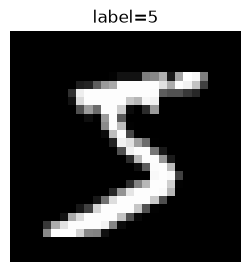

In [5]:
image, label = train_dataset[0]
print('single image shape:', image.shape)
print('label:', label)

plt.figure(figsize=(3, 3))
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f'label={label}')
plt.axis('off')
plt.show()

In [6]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

X_batch, y_batch = next(iter(train_loader))
print('batch images:', X_batch.shape)
print('batch labels:', y_batch.shape)

batch images: torch.Size([128, 1, 28, 28])
batch labels: torch.Size([128])


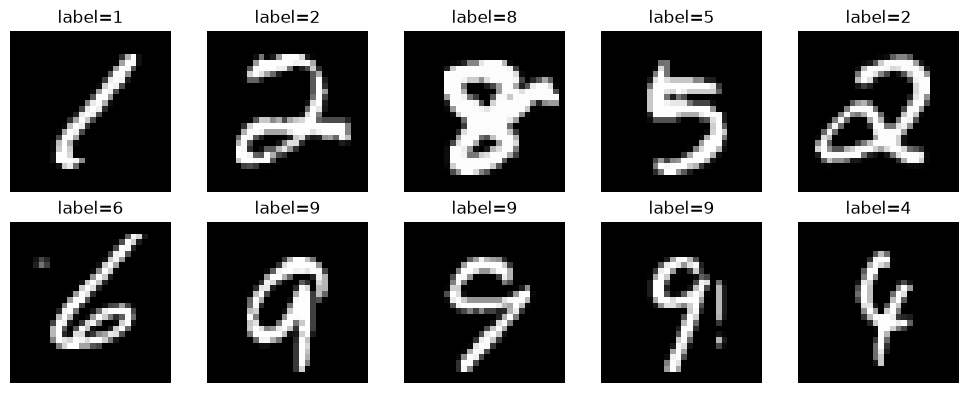

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, img, label in zip(axes.ravel(), X_batch[:10], y_batch[:10]):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'label={label.item()}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
class MNISTMLP(nn.Module):
    def __init__(self, input_size=28*28, hidden1=128, hidden2=64, num_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

model = MNISTMLP().to(device)
print(model)

MNISTMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [9]:
learning_rate = 1e-3
epochs = 5

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)

            running_loss += loss.item() * X.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return running_loss / total, correct / total

In [11]:
history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': [],
}

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"test_loss={test_loss:.4f} test_acc={test_acc:.4f}"
    )

Epoch 01 | train_loss=0.4085 train_acc=0.8910 | test_loss=0.2058 test_acc=0.9369
Epoch 02 | train_loss=0.1691 train_acc=0.9502 | test_loss=0.1357 test_acc=0.9590
Epoch 03 | train_loss=0.1169 train_acc=0.9658 | test_loss=0.1117 test_acc=0.9661
Epoch 04 | train_loss=0.0896 train_acc=0.9729 | test_loss=0.0951 test_acc=0.9715
Epoch 05 | train_loss=0.0713 train_acc=0.9788 | test_loss=0.0812 test_acc=0.9740


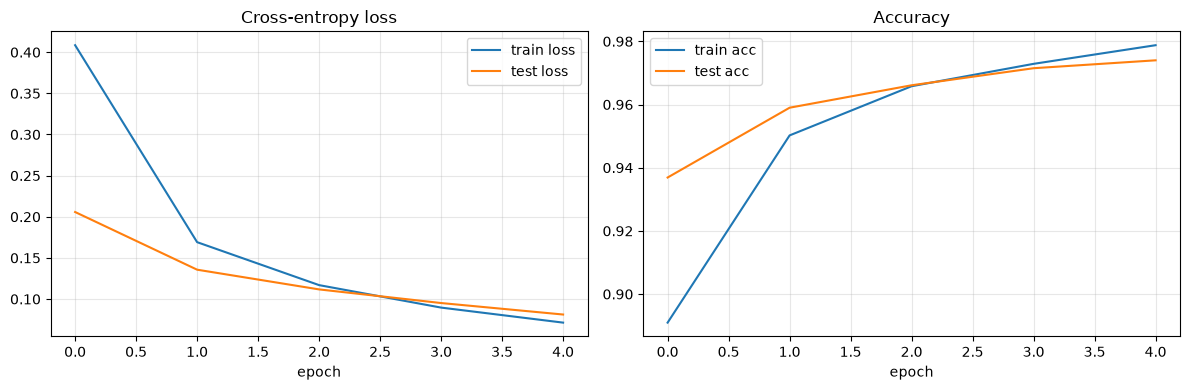

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='train loss')
axes[0].plot(history['test_loss'], label='test loss')
axes[0].set_title('Cross-entropy loss')
axes[0].set_xlabel('epoch')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(history['train_acc'], label='train acc')
axes[1].plot(history['test_acc'], label='test acc')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('epoch')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

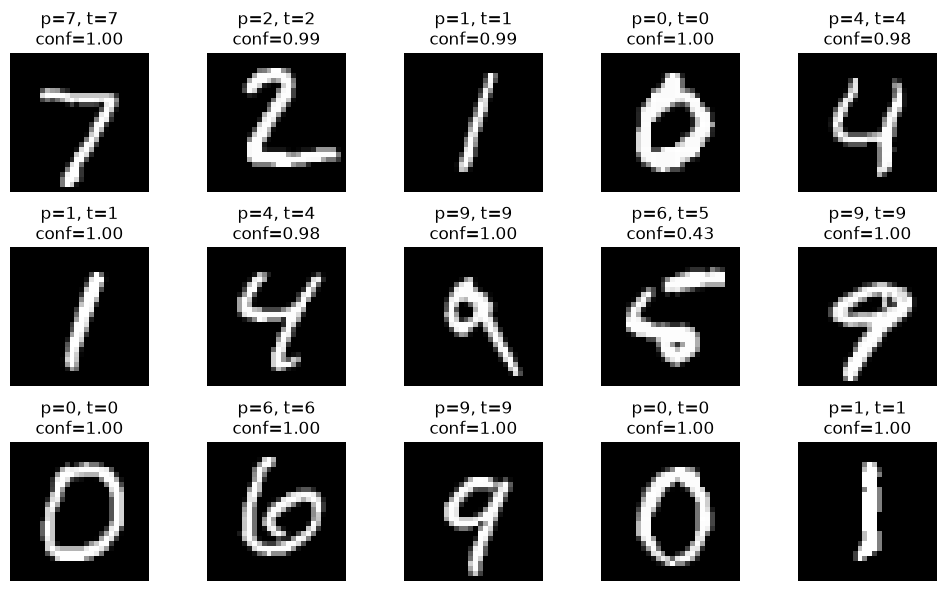

In [13]:
model.eval()
X_vis, y_vis = next(iter(test_loader))
X_vis_device = X_vis.to(device)

with torch.no_grad():
    logits = model(X_vis_device)
    probs = torch.softmax(logits, dim=1)
    preds = logits.argmax(dim=1).cpu()
    confs = probs.max(dim=1).values.cpu()

fig, axes = plt.subplots(3, 5, figsize=(10, 6))
for ax, img, pred, true, conf in zip(axes.ravel(), X_vis[:15], preds[:15], y_vis[:15], confs[:15]):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'p={pred.item()}, t={true.item()}\nconf={conf.item():.2f}')
    ax.axis('off')
plt.tight_layout()
plt.show()

mistakes in sampled batch: 2


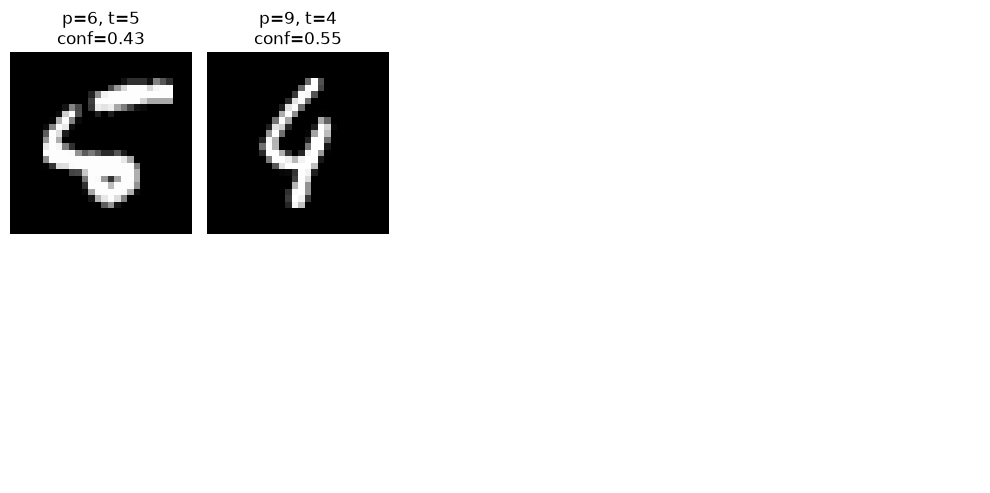

In [14]:
wrong = preds != y_vis
wrong_idx = torch.where(wrong)[0]
print('mistakes in sampled batch:', len(wrong_idx))

if len(wrong_idx) > 0:
    n = min(10, len(wrong_idx))
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.ravel(), wrong_idx[:n]):
        img = X_vis[idx]
        pred = preds[idx].item()
        true = y_vis[idx].item()
        conf = confs[idx].item()
        ax.imshow(img.squeeze(), cmap='gray')
        ax.set_title(f'p={pred}, t={true}\nconf={conf:.2f}')
        ax.axis('off')

    for ax in axes.ravel()[n:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [15]:
os.makedirs('artifacts', exist_ok=True)
model_path = 'artifacts/mnist_mlp_state_dict.pth'
torch.save(model.state_dict(), model_path)
print('saved to:', model_path)

saved to: artifacts/mnist_mlp_state_dict.pth


In [16]:
loaded_model = MNISTMLP().to(device)
loaded_model.load_state_dict(torch.load(model_path, map_location=device))
loaded_model.eval()

with torch.no_grad():
    sample_logits = loaded_model(X_vis[:8].to(device))
    sample_preds = sample_logits.argmax(dim=1).cpu().numpy()

print('loaded model predictions:', sample_preds)
print('ground truth           :', y_vis[:8].numpy())

loaded model predictions: [7 2 1 0 4 1 4 9]
ground truth           : [7 2 1 0 4 1 4 9]
